Training a DCGAN on the Fashion-MNIST Dataset

This notebook trains a DCGAN (Deep Convolutional GAN) on Fashion-MNIST — a generator that learns to produce clothing images from random noise, and a discriminator that learns to tell real images apart from generated ones. They're trained against each other, which is the whole idea behind GANs.

Best run in Google Colab with a GPU (Runtime > Change runtime type > T4 GPU), then just Run all. Takes about 10-20 minutes on GPU. It saves a 4x4 grid of generated images every 5 epochs to a generated_images folder so you can actually watch the outputs improve, and logs the generator/discriminator loss each epoch.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.utils as vutils
import matplotlib.pyplot as plt
import numpy as np
import os

torch.manual_seed(42)

if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print('Using device:', device)

Using device: cpu


Loading Fashion-MNIST and normalizing pixel values to [-1, 1] instead of [0, 1] — this matters because the generator's last layer uses Tanh, which only outputs values in that range, so the real and fake images need to be on the same scale.

100%|██████████| 26.4M/26.4M [00:01<00:00, 19.1MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 302kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.60MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 20.3MB/s]

Dataset size: 60000 images, 468 batches per epoch


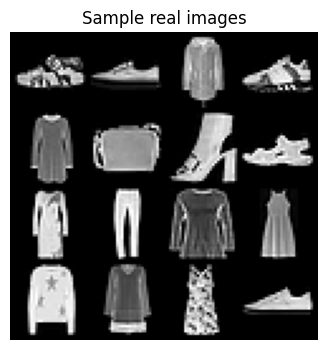

In [2]:
BATCH_SIZE = 128
IMAGE_SIZE = 28
NUM_CHANNELS = 1
LATENT_DIM = 100

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=True, download=True, transform=transform
)

dataloader = torch.utils.data.DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, drop_last=True
)

print(f'Dataset size: {len(train_dataset)} images, {len(dataloader)} batches per epoch')

real_batch = next(iter(dataloader))
plt.figure(figsize=(4, 4))
plt.axis('off')
plt.title('Sample real images')
plt.imshow(np.transpose(vutils.make_grid(real_batch[0][:16], nrow=4, padding=2, normalize=True), (1, 2, 0)))
plt.show()

The DCGAN paper initializes all weights from a Normal distribution (mean 0, std 0.02) instead of the default PyTorch init. It's a small detail but it noticeably helps training stability, so worth keeping.

In [3]:
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

Generator — takes a random 100-dim noise vector and upsamples it into a 28x28 image using transposed convolutions. First a linear layer projects the noise into a small 128x7x7 feature map, then two transposed conv layers upsample it to 14x14 and finally 28x28.

In [4]:
class Generator(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM):
        super().__init__()
        self.project = nn.Sequential(
            nn.Linear(latent_dim, 128 * 7 * 7),
            nn.BatchNorm1d(128 * 7 * 7),
            nn.ReLU(True)
        )
        self.main = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.ConvTranspose2d(64, NUM_CHANNELS, kernel_size=4, stride=2, padding=1, bias=False),
            nn.Tanh()
        )

    def forward(self, z):
        x = self.project(z)
        x = x.view(-1, 128, 7, 7)
        return self.main(x)

Discriminator — a fairly standard conv classifier. Two strided conv layers bring a 28x28 image down to a 7x7 feature map, then a linear + sigmoid gives a real/fake probability. LeakyReLU instead of regular ReLU is the usual DCGAN choice here.

In [5]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.main = nn.Sequential(
            nn.Conv2d(NUM_CHANNELS, 64, kernel_size=4, stride=2, padding=1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
        )
        self.classify = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 7 * 7, 1),
            nn.Sigmoid()
        )

    def forward(self, img):
        x = self.main(img)
        return self.classify(x).view(-1)

Setting up both models, the loss function, and optimizers. Using the settings from the original DCGAN paper — Adam with lr=0.0002 and beta1=0.5 works a lot better here than the Adam defaults. Also creating one fixed noise vector up front so the same 16 outputs get tracked across every saved grid, instead of comparing different random noise each time.

In [6]:
generator = Generator().to(device)
generator.apply(weights_init)

discriminator = Discriminator().to(device)
discriminator.apply(weights_init)

criterion = nn.BCELoss()

LR = 0.0002
BETA1 = 0.5
optimizer_G = optim.Adam(generator.parameters(), lr=LR, betas=(BETA1, 0.999))
optimizer_D = optim.Adam(discriminator.parameters(), lr=LR, betas=(BETA1, 0.999))

REAL_LABEL = 1.0
FAKE_LABEL = 0.0

fixed_noise = torch.randn(16, LATENT_DIM, device=device)

print(generator)
print(discriminator)

Generator(
  (project): Sequential(
    (0): Linear(in_features=100, out_features=6272, bias=True)
    (1): BatchNorm1d(6272, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (main): Sequential(
    (0): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(64, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): Tanh()
  )
)
Discriminator(
  (main): Sequential(
    (0): Conv2d(1, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
  )
  (classify): 

In [7]:
os.makedirs('generated_images', exist_ok=True)

def save_image_grid(gen, noise, epoch, save_dir='generated_images'):
    gen.eval()
    with torch.no_grad():
        fake = gen(noise).detach().cpu()
    grid = vutils.make_grid(fake, nrow=4, padding=2, normalize=True)

    plt.figure(figsize=(4, 4))
    plt.axis('off')
    plt.title(f'Epoch {epoch}')
    plt.imshow(np.transpose(grid, (1, 2, 0)), cmap='gray')
    filepath = os.path.join(save_dir, f'epoch_{epoch:03d}.png')
    plt.savefig(filepath, bbox_inches='tight')
    plt.show()
    plt.close()
    gen.train()
    return filepath

Training loop. Each batch, the discriminator sees a batch of real images (labeled 1) and a batch of freshly generated fake images (labeled 0) and updates to get better at telling them apart. Then the generator gets updated to try to fool the discriminator into predicting 1 for its fakes. Running this for 30 epochs, saving a grid every 5, and logging the average loss per epoch for both networks.

In [ ]:
NUM_EPOCHS = 30
SAVE_EVERY = 5

g_losses = []
d_losses = []
saved_grid_paths = []

for epoch in range(1, NUM_EPOCHS + 1):
    epoch_g_loss = 0.0
    epoch_d_loss = 0.0

    for real_images, _ in dataloader:
        real_images = real_images.to(device)
        current_batch_size = real_images.size(0)

        # discriminator step: real batch + fake batch
        discriminator.zero_grad()
        labels_real = torch.full((current_batch_size,), REAL_LABEL, dtype=torch.float, device=device)
        output_real = discriminator(real_images)
        loss_d_real = criterion(output_real, labels_real)

        noise = torch.randn(current_batch_size, LATENT_DIM, device=device)
        fake_images = generator(noise)
        labels_fake = torch.full((current_batch_size,), FAKE_LABEL, dtype=torch.float, device=device)
        output_fake = discriminator(fake_images.detach())
        loss_d_fake = criterion(output_fake, labels_fake)

        loss_d = loss_d_real + loss_d_fake
        loss_d.backward()
        optimizer_D.step()

        # generator step: wants discriminator to call its fakes real
        generator.zero_grad()
        output = discriminator(fake_images)
        loss_g = criterion(output, labels_real)
        loss_g.backward()
        optimizer_G.step()

        epoch_d_loss += loss_d.item()
        epoch_g_loss += loss_g.item()

    avg_g_loss = epoch_g_loss / len(dataloader)
    avg_d_loss = epoch_d_loss / len(dataloader)
    g_losses.append(avg_g_loss)
    d_losses.append(avg_d_loss)

    print(f'Epoch [{epoch}/{NUM_EPOCHS}]  Loss_D: {avg_d_loss:.4f}  Loss_G: {avg_g_loss:.4f}')

    if epoch % SAVE_EVERY == 0:
        path = save_image_grid(generator, fixed_noise, epoch)
        saved_grid_paths.append((epoch, path))

print('done training')

Epoch [1/30]  Loss_D: 0.2773  Loss_G: 2.6265


Plotting both losses over the full training run.

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, NUM_EPOCHS + 1), g_losses, label='Generator loss')
plt.plot(range(1, NUM_EPOCHS + 1), d_losses, label='Discriminator loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('DCGAN Training Losses on Fashion-MNIST')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('generated_images/loss_curve.png', bbox_inches='tight')
plt.show()

Putting all the saved grids side by side to see the progression across epochs in one view.

In [ ]:
n = len(saved_grid_paths)
fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
if n == 1:
    axes = [axes]

for ax, (epoch, path) in zip(axes, saved_grid_paths):
    img = plt.imread(path)
    ax.imshow(img)
    ax.set_title(f'Epoch {epoch}')
    ax.axis('off')

plt.tight_layout()
plt.savefig('generated_images/epoch_comparison.png', bbox_inches='tight')
plt.show()

Looking at the saved grids, the early epochs are basically just noise and static — the generator hasn't learned anything meaningful yet, and the discriminator can tell real from fake almost instantly. As training continues, the generator starts producing rough silhouettes, and somewhere in the middle epochs actual clothing shapes (shirts, trousers, shoes) start becoming recognizable, even if a bit blurry. Image quality usually keeps improving gradually rather than hitting a hard plateau within 30 epochs, though the gains slow down noticeably in the later epochs. On the loss plot, a stable run tends to have both losses fluctuating but staying roughly in the same range as each other, rather than one collapsing toward zero — if the discriminator loss drops very low while the generator loss keeps climbing, that's the discriminator overpowering the generator, which shows up as mode collapse or repetitive-looking outputs.

Update the above with what actually shows up in your own grids and loss curve before submitting, since the exact epoch where shapes sharpen up and whether any instability shows up will depend on your specific run.